# Data Cleaning, Feature Engineering & Outlier Handling

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('Data/H1.csv')

df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.shape

(40060, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  object 
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  object 
 12  Country                      39596 non-null  object 
 13  MarketSegment   

In [5]:
df.describe()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,BookingChanges,DaysInWaitingList,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests
count,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.000000,40060.00000
mean,0.277634,92.675686,2016.121443,27.140864,15.821243,1.189815,3.128732,1.867149,0.128682,0.013904,0.044383,0.101722,0.146455,0.287968,0.527758,94.952930,0.138068,0.61977
std,0.447837,97.285315,0.722347,14.005441,8.883708,1.147812,2.461329,0.697285,0.445195,0.118998,0.205948,1.335115,1.001955,0.726548,7.428580,61.442418,0.351001,0.81393
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.00000
25%,0.000000,10.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.00000
50%,0.000000,57.000000,2016.000000,28.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,75.000000,0.000000,0.00000
75%,1.000000,155.000000,2017.000000,38.000000,24.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,125.000000,0.000000,1.00000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,2.000000,1.000000,26.000000,30.000000,17.000000,185.000000,508.000000,8.000000,5.00000


## 2. Handle 'NULL' Text Values & Missing Value Treatment

In [7]:
# Strip spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Replace NULL-like values
null_values = ['NULL', 'null', 'NaN', 'nan', 'None', '']
df = df.replace(null_values, np.nan)


In [8]:
df.isnull().sum()

IsCanceled                         0
LeadTime                           0
ArrivalDateYear                    0
ArrivalDateMonth                   0
ArrivalDateWeekNumber              0
ArrivalDateDayOfMonth              0
StaysInWeekendNights               0
StaysInWeekNights                  0
Adults                             0
Children                           0
Babies                             0
Meal                               0
Country                          464
MarketSegment                      0
DistributionChannel                0
IsRepeatedGuest                    0
PreviousCancellations              0
PreviousBookingsNotCanceled        0
ReservedRoomType                   0
AssignedRoomType                   0
BookingChanges                     0
DepositType                        0
Agent                           8209
Company                        36952
DaysInWaitingList                  0
CustomerType                       0
ADR                                0
R

In [9]:
df['Country'] = df['Country'].fillna('Unknown')

In [10]:
df.isnull().sum()

IsCanceled                         0
LeadTime                           0
ArrivalDateYear                    0
ArrivalDateMonth                   0
ArrivalDateWeekNumber              0
ArrivalDateDayOfMonth              0
StaysInWeekendNights               0
StaysInWeekNights                  0
Adults                             0
Children                           0
Babies                             0
Meal                               0
Country                            0
MarketSegment                      0
DistributionChannel                0
IsRepeatedGuest                    0
PreviousCancellations              0
PreviousBookingsNotCanceled        0
ReservedRoomType                   0
AssignedRoomType                   0
BookingChanges                     0
DepositType                        0
Agent                           8209
Company                        36952
DaysInWaitingList                  0
CustomerType                       0
ADR                                0
R

In [11]:
df.drop(['Agent','Company'],axis=1,inplace=True)

In [12]:
df.isnull().sum()

IsCanceled                     0
LeadTime                       0
ArrivalDateYear                0
ArrivalDateMonth               0
ArrivalDateWeekNumber          0
ArrivalDateDayOfMonth          0
StaysInWeekendNights           0
StaysInWeekNights              0
Adults                         0
Children                       0
Babies                         0
Meal                           0
Country                        0
MarketSegment                  0
DistributionChannel            0
IsRepeatedGuest                0
PreviousCancellations          0
PreviousBookingsNotCanceled    0
ReservedRoomType               0
AssignedRoomType               0
BookingChanges                 0
DepositType                    0
DaysInWaitingList              0
CustomerType                   0
ADR                            0
RequiredCarParkingSpaces       0
TotalOfSpecialRequests         0
ReservationStatus              0
ReservationStatusDate          0
dtype: int64

## 3. Remove Duplicates

In [13]:
df.duplicated().sum()

np.int64(6104)

In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

## 4.Standardize Column Names

In [16]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [17]:
df.head()

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,assignedroomtype,bookingchanges,deposittype,daysinwaitinglist,customertype,adr,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate
0,0,342,2015,July,27,1,0,0,2,0,...,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33956 entries, 0 to 40059
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   iscanceled                   33956 non-null  int64  
 1   leadtime                     33956 non-null  int64  
 2   arrivaldateyear              33956 non-null  int64  
 3   arrivaldatemonth             33956 non-null  object 
 4   arrivaldateweeknumber        33956 non-null  int64  
 5   arrivaldatedayofmonth        33956 non-null  int64  
 6   staysinweekendnights         33956 non-null  int64  
 7   staysinweeknights            33956 non-null  int64  
 8   adults                       33956 non-null  int64  
 9   children                     33956 non-null  int64  
 10  babies                       33956 non-null  int64  
 11  meal                         33956 non-null  object 
 12  country                      33956 non-null  object 
 13  marketsegment        

## 5. Feature Engineering

In [23]:
df['total_guests'] = df['Adults'] + df['Children'] + df['Babies']

In [24]:
df['total_stay'] = df['StaysInWeekendNights'] + df['StaysInWeekNights']

In [25]:
df['revenue'] = df['ADR'] * df['total_stay']

In [26]:
month_map = {
"January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
"July":7,"August":8,"September":9,"October":10,"November":11,"December":12
}

df["arrival_month_number"] = df["ArrivalDateMonth"].map(month_map)

In [30]:
df.isnull().sum()

IsCanceled                     0
LeadTime                       0
ArrivalDateYear                0
ArrivalDateMonth               0
ArrivalDateWeekNumber          0
ArrivalDateDayOfMonth          0
StaysInWeekendNights           0
StaysInWeekNights              0
Adults                         0
Children                       0
Babies                         0
Meal                           0
Country                        0
MarketSegment                  0
DistributionChannel            0
IsRepeatedGuest                0
PreviousCancellations          0
PreviousBookingsNotCanceled    0
ReservedRoomType               0
AssignedRoomType               0
BookingChanges                 0
DepositType                    0
Agent                          0
Company                        0
DaysInWaitingList              0
CustomerType                   0
ADR                            0
RequiredCarParkingSpaces       0
TotalOfSpecialRequests         0
ReservationStatus              0
Reservatio

In [31]:
total_revenue = df['revenue'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 15686837.770000001


## 6. Outlier Removal (IQR Method)

In [19]:
# Remove negative ADR (invalid)
df_cleanednegative = df[df['adr'] >= 0]

In [20]:
df_cleanednegative.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33955 entries, 0 to 40059
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   iscanceled                   33955 non-null  int64  
 1   leadtime                     33955 non-null  int64  
 2   arrivaldateyear              33955 non-null  int64  
 3   arrivaldatemonth             33955 non-null  object 
 4   arrivaldateweeknumber        33955 non-null  int64  
 5   arrivaldatedayofmonth        33955 non-null  int64  
 6   staysinweekendnights         33955 non-null  int64  
 7   staysinweeknights            33955 non-null  int64  
 8   adults                       33955 non-null  int64  
 9   children                     33955 non-null  int64  
 10  babies                       33955 non-null  int64  
 11  meal                         33955 non-null  object 
 12  country                      33955 non-null  object 
 13  marketsegment        

In [21]:
df_cleanednegative['adr'].max()

508.0

In [22]:
Q1 = df_cleanednegative['adr'].quantile(0.25)
Q3 = df_cleanednegative['adr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower, "Upper:", upper)

Lower: -72.38249999999996 Upper: 257.9575


In [24]:
upper = df_cleanednegative['adr'].quantile(0.99)
lower = df_cleanednegative['adr'].quantile(0.01)

df_cleanednegative['adr']=df_cleanednegative['adr'].clip(lower, upper)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13672\2525969920.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleanednegative['adr']=df_cleanednegative['adr'].clip(lower, upper)


In [25]:
# Optional: normalize
df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_13672\2951147565.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])


In [26]:
df_cleanednegative

,iscanceled,leadtime,arrivaldateyear,arrivaldatemonth,arrivaldateweeknumber,arrivaldatedayofmonth,staysinweekendnights,staysinweeknights,adults,children,...,bookingchanges,deposittype,daysinwaitinglist,customertype,adr,requiredcarparkingspaces,totalofspecialrequests,reservationstatus,reservationstatusdate,adr_log
0,0,342,2015,July,27,1,0,0,2,0,...,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,0.000000
1,0,737,2015,July,27,1,0,0,2,0,...,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,0.000000
2,0,7,2015,July,27,1,0,1,1,0,...,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,4.330733
3,0,13,2015,July,27,1,0,1,1,0,...,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,4.330733
4,0,14,2015,July,27,1,0,2,2,0,...,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03,4.595120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40055,0,212,2017,August,35,31,2,8,2,1,...,1,No Deposit,0,Transient,89.75,0,0,Check-Out,2017-09-10,4.508108
40056,0,169,2017,August,35,30,2,9,2,0,...,0,No Deposit,0,Transient-Party,202.27,0,1,Check-Out,2017-09-10,5.314535
40057,0,204,2017,August,35,29,4,10,2,0,...,0,No Deposit,0,Transient,153.57,0,3,Check-Out,2017-09-12,5.040647
40058,0,211,2017,August,35,31,4,10,2,0,...,0,No Deposit,0,Contract,112.80,0,1,Check-Out,2017-09-14,4.734443


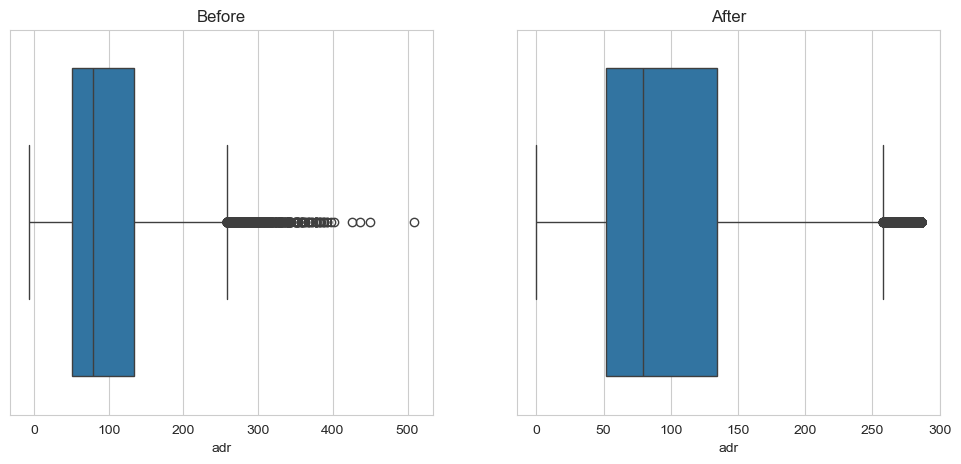

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['adr'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x=df_cleanednegative['adr'])
plt.title("After")

plt.show()

In [28]:
df.to_csv("cleaned_hotel_bookings.csv", index=False)